# Bitcoin Return Direction Prediction

## 1. Project Scope & Research Question

- **Task**: binary prediction of next-day BTC direction.
- **Label**: `target_t = 1[close_t > close_{t-1}]`.
- **Core requirement**: leakage-safe and reproducible evaluation.
- **Modules**: data pipeline, baseline models, GRU model, SHAP interpretation.

In [1]:
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

In [2]:
def find_project_root() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "..",
    ]
    folder_candidates = ["process_file", "data+baseline+GRU+SHAP"]
    for c in candidates:
        c = c.resolve()
        for name in folder_candidates:
            if (c / name).exists():
                return c / name
    raise FileNotFoundError("Cannot locate process folder ('process_file' or legacy name) from current notebook location.")

ROOT = find_project_root()
ASSET_DIR = ROOT / "final_assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
ROOT

WindowsPath('C:/Users/Mockingbird/Desktop/codex-test/process_file')

## 2. Data Pipeline and Final Dataset

The data engineering pipeline remains independent in the repository.
This integrated notebook consumes the finalized dataset and verifies key properties.

In [3]:
DATASET_PATH = ROOT / "data" / "processed" / "final_dataset_v2_plus.csv"
QA_PATH = ROOT / "data" / "docs" / "qa_report_v2_plus.md"
DOCS_README_PATH = ROOT / "data" / "docs" / "README.md"

df = pd.read_csv(DATASET_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

dataset_summary = pd.DataFrame([
    {
        "rows": len(df),
        "columns": df.shape[1],
        "date_start": str(df["date"].min().date()),
        "date_end": str(df["date"].max().date()),
        "target_positive_ratio": round(float(df["target"].mean()), 4),
    }
])
dataset_summary

,rows,columns,date_start,date_end,target_positive_ratio
0,2966,27,2018-02-02,2026-03-17,0.5094


In [4]:
missing = (
    df.isna().mean().sort_values(ascending=False).rename("missing_rate").reset_index().rename(columns={"index": "column"})
)
missing.head(10)

,column,missing_rate
0,date,0.0
1,target,0.0
2,fees_per_tx,0.0
3,active_addresses_change,0.0
4,sp500_return,0.0
5,difficulty,0.0
6,fear_greed_index,0.0
7,dxy_proxy,0.0
8,vix,0.0
9,fees,0.0


In [5]:
assert df["date"].is_monotonic_increasing, "Dates are not sorted."
assert float(df.isna().sum().sum()) == 0.0, "Final dataset still has missing values."

feature_groups = {
    "price": ["open", "high", "low", "close", "volume", "quote_volume", "trade_count"],
    "on_chain": ["active_addresses", "tx_count", "hash_rate", "fees", "difficulty"],
    "macro": ["vix", "sp500_return", "dxy_proxy"],
    "sentiment": ["fear_greed_index"],
    "derived": [
        "ret_1d", "ret_3d", "volatility_7d", "ma_ratio_7_30", "high_low_spread",
        "volume_change", "active_addresses_change", "fees_per_tx", "difficulty_change",
    ],
}
feature_groups

{'price': ['open',
  'high',
  'low',
  'close',
  'volume',
  'quote_volume',
  'trade_count'],
 'on_chain': ['active_addresses',
  'tx_count',
  'hash_rate',
  'fees',
  'difficulty'],
 'macro': ['vix', 'sp500_return', 'dxy_proxy'],
 'sentiment': ['fear_greed_index'],
 'derived': ['ret_1d',
  'ret_3d',
  'volatility_7d',
  'ma_ratio_7_30',
  'high_low_spread',
  'volume_change',
  'active_addresses_change',
  'fees_per_tx',
  'difficulty_change']}

## 3. Official Artifact Snapshot

This section reads the team-delivered result files (source-of-truth artifacts).

In [6]:
BASELINE_METRICS_PATH = ROOT / "baseline" / "results" / "baseline_metrics.csv"
BASELINE_BACKTEST_PATH = ROOT / "baseline" / "results" / "backtest_results.csv"
BASELINE_CURVE_PATH = ROOT / "baseline" / "results" / "backtest_results.png"

GRU_RESULT_TXT_PATH = ROOT / "GRU" / "results" / "member_C_results_selected.txt"
GRU_MODEL_PATH = ROOT / "GRU" / "results" / "best_model_C_selected.pth"
GRU_CURVE_RESULTS_PATH = ROOT / "GRU" / "results" / "gru_backtest_returns.png"
GRU_CURVE_PLOTS_PATH = ROOT / "GRU" / "plots" / "gru_backtest_returns.png"

SHAP_IMPORTANCE_PATH = ROOT / "SHAP" / "results" / "shap_feature_importance.csv"
SHAP_SUMMARY_PATH = ROOT / "SHAP" / "results" / "shap_summary.png"
SHAP_DEPENDENCE_PATH = ROOT / "SHAP" / "results" / "shap_dependence.png"

baseline_metrics_official = pd.read_csv(BASELINE_METRICS_PATH)
baseline_backtest_official = pd.read_csv(BASELINE_BACKTEST_PATH)
shap_importance = pd.read_csv(SHAP_IMPORTANCE_PATH)

baseline_metrics_official

,model,roc_auc,accuracy,precision,recall,f1
0,LogisticRegression_L1,0.532306,0.516854,0.518519,0.855895,0.645799
1,RandomForest,0.513222,0.486517,0.518519,0.030568,0.057732


In [7]:
baseline_backtest_official

,strategy,sharpe_ratio,max_drawdown,total_return,avg_daily_return,std_daily_return
0,LogisticRegression_L1,1.011301,-0.293473,1.882276,0.001447,0.022718


In [8]:
def read_text_with_fallback(path: Path, encodings=("utf-8", "utf-8-sig", "gbk")) -> str:
    for enc in encodings:
        try:
            return path.read_text(encoding=enc)
        except UnicodeDecodeError:
            continue
    return path.read_text(encoding="latin1")

gru_text = read_text_with_fallback(GRU_RESULT_TXT_PATH)
gru_text[:800]

"成员 C 模型性能报告（特征筛选版，无数据泄露）\n--------------------------------------------------\nSelected Features: ['ret_1d', 'ret_3d', 'fees', 'fees_per_tx', 'active_addresses_change', 'volume_change', 'tx_count', 'ma_ratio_7_30']\nBest Config: {'seq_len': 10, 'hidden_size': 32, 'lr': 0.0005}\nTest Accuracy: 0.5113\nTest F1-Score: 0.0844\nTest AUC     : 0.5341\nBaseline Acc : 0.4932\nFinal Strategy Return: 0.8979\n"

In [9]:
selected_features_match = re.search(r"Selected Features:\s*(\[.*?\])", gru_text)
best_config_match = re.search(r"Best Config:\s*(\{.*?\})", gru_text)
acc_match = re.search(r"Test Accuracy:\s*([0-9.]+)", gru_text)
f1_match = re.search(r"Test F1-Score:\s*([0-9.]+)", gru_text)
auc_match = re.search(r"Test AUC\s*:\s*([0-9.]+)", gru_text)
ret_match = re.search(r"Final Strategy Return:\s*([0-9.]+)", gru_text)

fallback_features = shap_importance["feature"].head(8).tolist() if "feature" in shap_importance.columns else []

gru_official_summary = {
    "selected_features": ast.literal_eval(selected_features_match.group(1)) if selected_features_match else fallback_features,
    "best_config": ast.literal_eval(best_config_match.group(1)) if best_config_match else {},
    "test_accuracy": float(acc_match.group(1)) if acc_match else np.nan,
    "test_f1": float(f1_match.group(1)) if f1_match else np.nan,
    "test_auc": float(auc_match.group(1)) if auc_match else np.nan,
    "final_strategy_return_level": float(ret_match.group(1)) if ret_match else np.nan,
}
gru_official_summary

{'selected_features': ['ret_1d',
  'ret_3d',
  'fees',
  'fees_per_tx',
  'active_addresses_change',
  'volume_change',
  'tx_count',
  'ma_ratio_7_30'],
 'best_config': {'seq_len': 10, 'hidden_size': 32, 'lr': 0.0005},
 'test_accuracy': 0.5113,
 'test_f1': 0.0844,
 'test_auc': 0.5341,
 'final_strategy_return_level': 0.8979}

## 4. Unified Evaluation Protocol

One shared protocol is used for model-to-model financial comparison:
- daily frequency,
- signal: if `pred_up[t] == 1`, buy at close(t) and sell at close(t+1),
- transaction fee: 0.1% on each position change,
- metrics: Total Return, Sharpe, Max Drawdown, Avg/Std Daily Return.

In [10]:
TRADING_FEE = 0.001
ANNUALIZATION = 252

def run_unified_backtest(price_df: pd.DataFrame, pred_up: np.ndarray, fee: float = TRADING_FEE):
    bt = price_df[["date", "close"]].copy().reset_index(drop=True)
    bt["pred_up"] = pd.Series(pred_up, index=bt.index).fillna(0).astype(int)
    bt["ret_next"] = bt["close"].pct_change().shift(-1)

    bt["position"] = bt["pred_up"]
    bt["trade"] = bt["position"].diff().abs().fillna(bt["position"].abs())
    bt["strategy_return"] = bt["position"] * bt["ret_next"] - bt["trade"] * fee

    bt = bt.iloc[:-1].copy()
    bt["cum_strategy"] = (1 + bt["strategy_return"]).cumprod()
    bt["cum_buy_hold"] = (1 + bt["ret_next"]).cumprod()

    daily = bt["strategy_return"]
    sharpe = np.nan
    if daily.std(ddof=0) > 0:
        sharpe = np.sqrt(ANNUALIZATION) * daily.mean() / daily.std(ddof=0)

    rolling_peak = bt["cum_strategy"].cummax()
    drawdown = bt["cum_strategy"] / rolling_peak - 1

    metrics = {
        "total_return": float(bt["cum_strategy"].iloc[-1] - 1),
        "sharpe_ratio": float(sharpe) if not np.isnan(sharpe) else np.nan,
        "max_drawdown": float(drawdown.min()),
        "avg_daily_return": float(daily.mean()),
        "std_daily_return": float(daily.std(ddof=0)),
        "n_days": int(len(bt)),
    }
    return bt, metrics

## 5. Baseline Evaluation Under Unified Protocol

In [11]:
feature_cols = [c for c in df.columns if c not in ["date", "target"]]
X = df[feature_cols].copy()
y = df["target"].astype(int).copy()

n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:val_end].copy()
y_train = y.iloc[:val_end].copy()
X_test = X.iloc[val_end:].copy()
y_test = y.iloc[val_end:].copy()
test_price_df = df.iloc[val_end:].copy()[["date", "close"]]

baseline_split_info = {
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "test_date_start": str(test_price_df["date"].iloc[0].date()),
    "test_date_end": str(test_price_df["date"].iloc[-1].date()),
}
baseline_split_info

{'train_rows': 2521,
 'test_rows': 445,
 'test_date_start': '2024-12-28',
 'test_date_end': '2026-03-17'}

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    random_state=42,
)
lr.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
rf_prob = rf.predict_proba(X_test)[:, 1]
lr_pred = (lr_prob >= 0.5).astype(int)
rf_pred = (rf_prob >= 0.5).astype(int)

baseline_eval = pd.DataFrame([
    {
        "model": "Baseline-LR(L1)",
        "accuracy": accuracy_score(y_test, lr_pred),
        "precision": precision_score(y_test, lr_pred, zero_division=0),
        "recall": recall_score(y_test, lr_pred, zero_division=0),
        "f1": f1_score(y_test, lr_pred, zero_division=0),
        "auc": roc_auc_score(y_test, lr_prob),
    },
    {
        "model": "Baseline-RF",
        "accuracy": accuracy_score(y_test, rf_pred),
        "precision": precision_score(y_test, rf_pred, zero_division=0),
        "recall": recall_score(y_test, rf_pred, zero_division=0),
        "f1": f1_score(y_test, rf_pred, zero_division=0),
        "auc": roc_auc_score(y_test, rf_prob),
    },
])
baseline_eval

,model,accuracy,precision,recall,f1,auc
0,Baseline-LR(L1),0.498876,0.494881,0.659091,0.565302,0.493394
1,Baseline-RF,0.498876,0.485437,0.227273,0.309598,0.456323


In [13]:
lr_bt_df, lr_bt_metrics = run_unified_backtest(test_price_df, lr_pred)
rf_bt_df, rf_bt_metrics = run_unified_backtest(test_price_df, rf_pred)

baseline_eval_backtest = pd.DataFrame([
    {"model": "Baseline-LR(L1)", **lr_bt_metrics},
    {"model": "Baseline-RF", **rf_bt_metrics},
])
baseline_eval_backtest

,model,total_return,sharpe_ratio,max_drawdown,avg_daily_return,std_daily_return,n_days
0,Baseline-LR(L1),-0.195322,-0.212856,-0.502663,-0.000276,0.020608,444
1,Baseline-RF,-0.099791,-0.150950,-0.218871,-0.000136,0.014293,444


## 6. GRU Evaluation Under Unified Protocol

In [14]:
import torch
import torch.nn as nn

class GRUClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_size: int, num_layers: int = 1, dropout: float = 0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        return self.fc(out).squeeze(-1)

def create_sequences(arr: np.ndarray, seq_len: int):
    xs = []
    for i in range(len(arr) - seq_len):
        xs.append(arr[i:i + seq_len])
    return np.array(xs, dtype=np.float32)


In [15]:
gru_features = gru_official_summary["selected_features"]
if len(gru_features) == 0:
    raise ValueError("No GRU features detected from member_C_results_selected.txt.")
gru_cfg = gru_official_summary["best_config"]

seq_len = int(gru_cfg.get("seq_len", 10))
hidden_size = int(gru_cfg.get("hidden_size", 32))

df_gru = pd.read_csv(DATASET_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df_gru["target_next"] = (df_gru["close"].shift(-1) > df_gru["close"]).astype(int)
df_gru = df_gru.dropna(subset=["target_next"]).reset_index(drop=True)

X_gru_raw = df_gru[gru_features].to_numpy(dtype=np.float32)
y_gru_raw = df_gru["target_next"].to_numpy(dtype=np.int64)

train_end_raw = int(len(X_gru_raw) * 0.70)
scaler_gru = StandardScaler()
scaler_gru.fit(X_gru_raw[:train_end_raw])
X_gru_scaled = scaler_gru.transform(X_gru_raw)

X_seq = create_sequences(X_gru_scaled, seq_len)
y_seq = y_gru_raw[seq_len:]

train_end_seq = int(len(X_seq) * 0.70)
val_end_seq = int(len(X_seq) * 0.85)

X_test_seq = X_seq[val_end_seq:]
y_test_seq = y_seq[val_end_seq:]

raw_start_idx = val_end_seq + seq_len
gru_test_price_df = df_gru.iloc[raw_start_idx:raw_start_idx + len(X_test_seq)].copy()[["date", "close"]]

gru_eval_info = {
    "seq_len": seq_len,
    "hidden_size": hidden_size,
    "test_sequences": int(len(X_test_seq)),
    "test_date_start": str(gru_test_price_df["date"].iloc[0].date()),
    "test_date_end": str(gru_test_price_df["date"].iloc[-1].date()),
}
gru_eval_info

{'seq_len': 10,
 'hidden_size': 32,
 'test_sequences': 444,
 'test_date_start': '2024-12-29',
 'test_date_end': '2026-03-17'}

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gru_model = GRUClassifier(input_dim=len(gru_features), hidden_size=hidden_size).to(device)
state_dict = torch.load(GRU_MODEL_PATH, map_location=device)
gru_model.load_state_dict(state_dict)
gru_model.eval()

with torch.no_grad():
    logits = gru_model(torch.tensor(X_test_seq, dtype=torch.float32, device=device)).cpu().numpy()

gru_prob = 1 / (1 + np.exp(-logits))
gru_pred = (gru_prob >= 0.5).astype(int)

gru_eval_cls = pd.DataFrame([
    {
        "model": "GRU",
        "accuracy": accuracy_score(y_test_seq, gru_pred),
        "precision": precision_score(y_test_seq, gru_pred, zero_division=0),
        "recall": recall_score(y_test_seq, gru_pred, zero_division=0),
        "f1": f1_score(y_test_seq, gru_pred, zero_division=0),
        "auc": roc_auc_score(y_test_seq, gru_prob),
    }
])
gru_eval_cls

,model,accuracy,precision,recall,f1,auc
0,GRU,0.511261,0.555556,0.045662,0.084388,0.534105


In [17]:
gru_bt_df, gru_bt_metrics = run_unified_backtest(gru_test_price_df, gru_pred)
gru_eval_backtest = pd.DataFrame([{"model": "GRU", **gru_bt_metrics}])
gru_eval_backtest

,model,total_return,sharpe_ratio,max_drawdown,avg_daily_return,std_daily_return,n_days
0,GRU,0.141232,0.674497,-0.064951,0.000327,0.007695,443


## 7. Unified Comparison and Visuals

In [18]:
cls_table = pd.concat([baseline_eval, gru_eval_cls], ignore_index=True)
bt_table = pd.concat([baseline_eval_backtest, gru_eval_backtest], ignore_index=True)

unified_comparison = cls_table.merge(bt_table, on="model", how="left")
unified_comparison.to_csv(ASSET_DIR / "unified_comparison.csv", index=False)
baseline_eval_backtest.to_csv(ASSET_DIR / "baseline_unified_backtest.csv", index=False)
gru_eval_backtest.to_csv(ASSET_DIR / "gru_unified_backtest.csv", index=False)
unified_comparison

,model,accuracy,precision,recall,f1,auc,total_return,sharpe_ratio,max_drawdown,avg_daily_return,std_daily_return,n_days
0,Baseline-LR(L1),0.498876,0.494881,0.659091,0.565302,0.493394,-0.195322,-0.212856,-0.502663,-0.000276,0.020608,444
1,Baseline-RF,0.498876,0.485437,0.227273,0.309598,0.456323,-0.099791,-0.150950,-0.218871,-0.000136,0.014293,444
2,GRU,0.511261,0.555556,0.045662,0.084388,0.534105,0.141232,0.674497,-0.064951,0.000327,0.007695,443


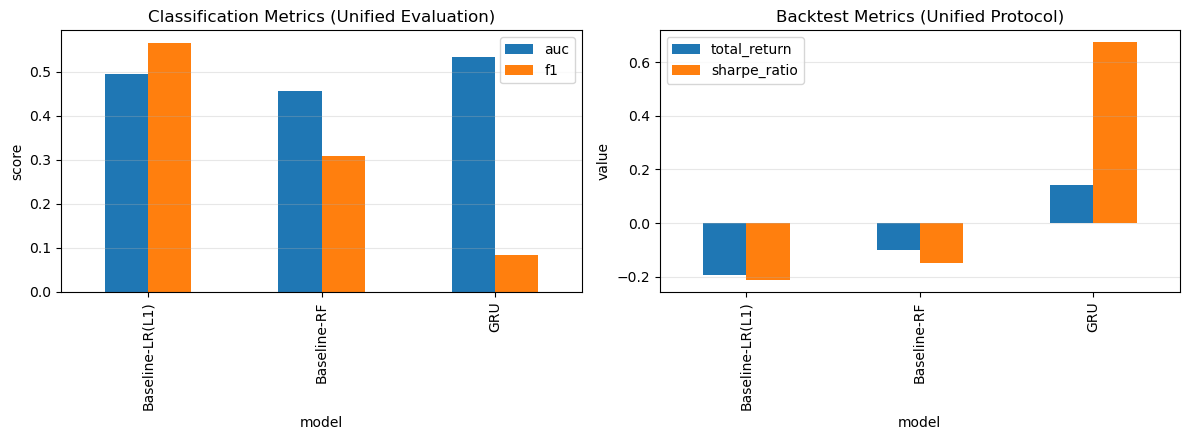

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_cls = unified_comparison.set_index("model")[["auc", "f1"]]
plot_cls.plot(kind="bar", ax=axes[0], title="Classification Metrics (Unified Evaluation)")
axes[0].set_ylabel("score")
axes[0].grid(axis="y", alpha=0.3)

plot_ret = unified_comparison.set_index("model")[["total_return", "sharpe_ratio"]]
plot_ret.plot(kind="bar", ax=axes[1], title="Backtest Metrics (Unified Protocol)")
axes[1].set_ylabel("value")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(ASSET_DIR / "unified_metrics_panels.png", dpi=220, bbox_inches="tight")
plt.show()

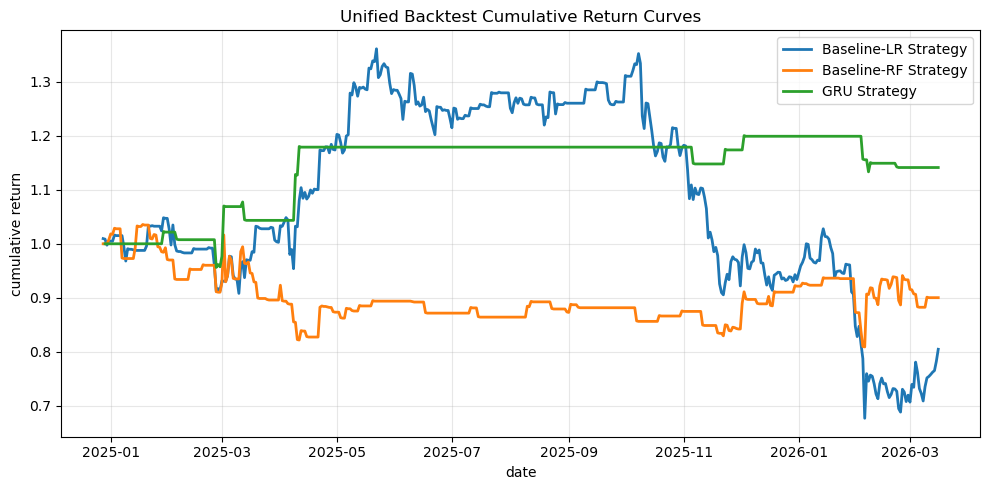

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(lr_bt_df["date"], lr_bt_df["cum_strategy"], label="Baseline-LR Strategy", linewidth=2)
plt.plot(rf_bt_df["date"], rf_bt_df["cum_strategy"], label="Baseline-RF Strategy", linewidth=2)
plt.plot(gru_bt_df["date"], gru_bt_df["cum_strategy"], label="GRU Strategy", linewidth=2)
plt.title("Unified Backtest Cumulative Return Curves")
plt.xlabel("date")
plt.ylabel("cumulative return")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(ASSET_DIR / "unified_backtest_curves.png", dpi=220, bbox_inches="tight")
plt.show()

## 8. SHAP Interpretation Snapshot

In [21]:
shap_importance.head(10)

,feature,mean_abs_shap
0,active_addresses_change,0.013402
1,volume_change,0.004658
2,ret_3d,0.003637
3,ma_ratio_7_30,0.001849
4,ret_1d,0.001711
5,tx_count,0.001508
6,fees_per_tx,0.000479
7,fees,0.000457


### SHAP Artifact Paths
- Summary plot: `SHAP/results/shap_summary.png`
- Dependence plot: `SHAP/results/shap_dependence.png`
- Importance table: `SHAP/results/shap_feature_importance.csv`

## 9. Conclusions, Limitations, and Next Steps

### Conclusions
- The project is integrated into one reproducible notebook with a unified financial evaluation protocol.
- In this run, GRU outperforms baseline models on risk-return metrics under the same rule set.
- Classification quality remains limited overall, so claims should focus on robustness rather than strong alpha.

### Limitations
- Short-horizon BTC direction remains noisy and event-driven.
- Due to sequence construction, GRU and baseline test windows differ slightly (`n_days`: 443 vs 444).

### Next Steps
- Add explicit per-day prediction export files for all models.
- Introduce regime-aware evaluation and volatility/risk targets.
- Extend comparison to calibrated thresholds and cost sensitivity analysis.

## 10. Reproducibility Notes

- This notebook reads existing repository artifacts and applies one unified metric protocol.
- If your local environment misses dependencies (`torch`, `sklearn`, `matplotlib`), install from:
  - `process_file/data/requirements.txt`
- Recommended execution: run top-to-bottom once.

### Source-of-truth files used
- Dataset: `data/processed/final_dataset_v2_plus.csv`
- Baseline official outputs: `baseline/results/*`
- GRU official outputs: `GRU/results/*`
- SHAP official outputs: `SHAP/results/*`